In [1]:
#Setup
import pandas as pd
import matplotlib.pyplot as plt

demand = pd.read_csv("../data/raw/demand.csv", parse_dates=["startTime"])
weather = pd.read_csv("../data/raw/weather.csv", parse_dates=["time"])

print(demand.shape, weather.shape)
demand.head()

(64316, 6) (32160, 3)


,publishTime,startTime,settlementDate,settlementPeriod,initialDemandOutturn,initialTransmissionSystemDemandOutturn
0,2023-01-01T00:30:00Z,2023-01-01 00:00:00+00:00,2023-01-01,1,20967,24872
1,2023-01-01T01:00:00Z,2023-01-01 00:30:00+00:00,2023-01-01,2,21699,25472
2,2023-01-01T01:30:00Z,2023-01-01 01:00:00+00:00,2023-01-01,3,21185,25381
3,2023-01-01T02:00:00Z,2023-01-01 01:30:00+00:00,2023-01-01,4,20442,24793
4,2023-01-01T02:30:00Z,2023-01-01 02:00:00+00:00,2023-01-01,5,19633,24420


Demand is half hourly across 48 settlement periods per day, weather is hourly. 64,316 and 32,160 rows respectively.

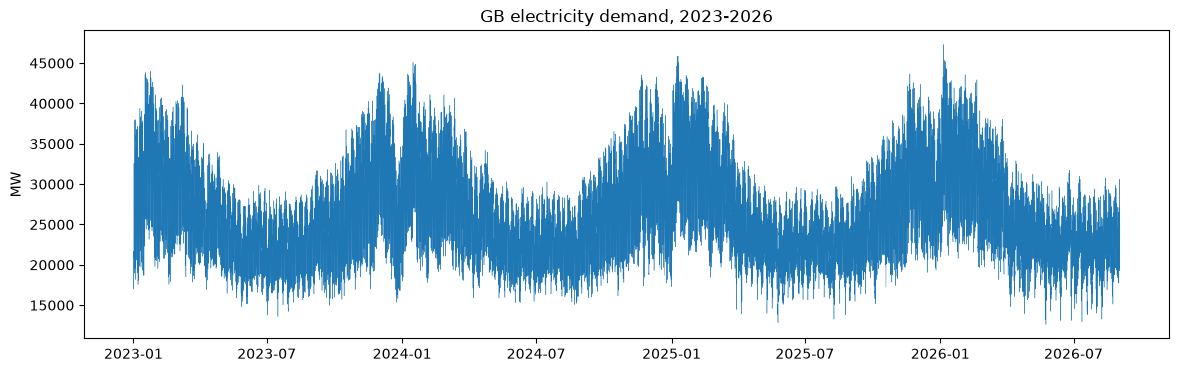

In [2]:
#Demand last 3 years
plt.figure(figsize=(14, 4))
plt.plot(demand["startTime"], demand["initialDemandOutturn"], linewidth=0.3)
plt.title("GB electricity demand, 2023-2026")
plt.ylabel("MW")
plt.show()

Demand follows an expected annual cycle, peaking in winter and decreasing in summer. Winter peaks reach roughly 43-45 GW against summer lows of roughly GW. No missing stretches or flat sections across the three years.

Winter peaks rise slightly each consecutive year (roughly 44 GW in 2023 to 47 GW in 2026), suggesting demand is trending upward.

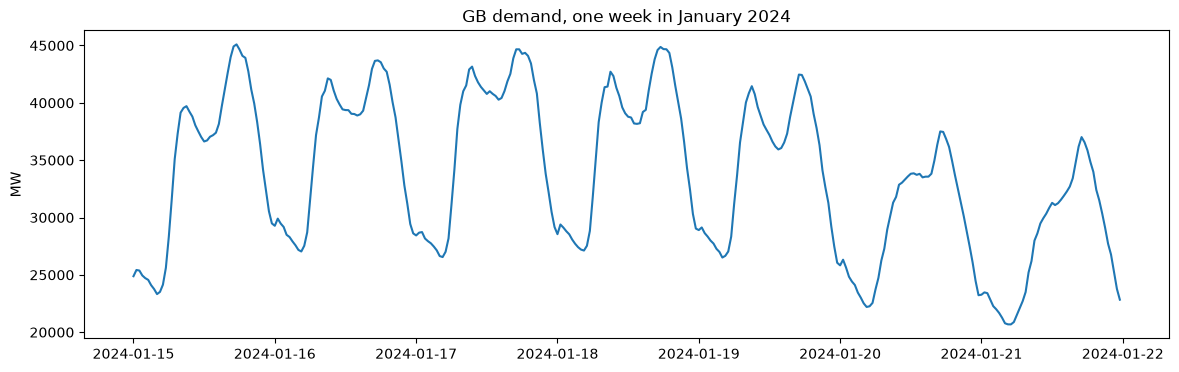

In [3]:
#Detailed 1 week demand data (15th Jan 2024 to 21st Jan 2024)
week = demand[(demand["startTime"] >= "2024-01-15") & (demand["startTime"] < "2024-01-22")]

plt.figure(figsize=(14, 4))
plt.plot(week["startTime"], week["initialDemandOutturn"])
plt.title("GB demand, one week in January 2024")
plt.ylabel("MW")
plt.show()

Weekdays show a double peak: a morning ramp to around 40 GW and a higher evening peak at 44–45 GW, separated by a midday dip. Weekends peak much lower at 33–37 GW, ramp later, and hold a flatter shape.

Peak to trough within a single day is roughly 2x, a larger difference than the seasonal comparison, so time of day is likely the strongest predictor. The weekday/weekend gap is wide enough to justify a day of week feature, and the daily and weekly repetition points to lags at 48 and 336 half hours.

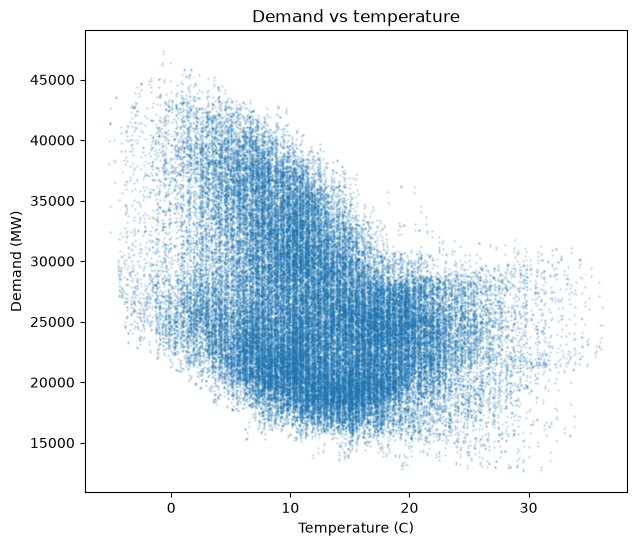

In [4]:
#Demand vs temperature
merged = demand.merge(weather, left_on=demand["startTime"].dt.floor("h").dt.tz_localize(None), right_on="time")

plt.figure(figsize=(7, 6))
plt.scatter(merged["temperature_2m"], merged["initialDemandOutturn"], s=1, alpha=0.15)
plt.xlabel("Temperature (C)")
plt.ylabel("Demand (MW)")
plt.title("Demand vs temperature")
plt.show()

Demand falls steadily with temperature below roughly 15°C, then flattens above it, consistent with low air conditioning use in GB. The relationship is piecewise, not linear, suggesting a heating degree day feature (max(0, 15.5 − T)) or a tree model that can find the threshold itself.

The wide vertical spread at any given temperature shows weather sets the seasonal envelope while time of day and day of week drive the variation inside it.

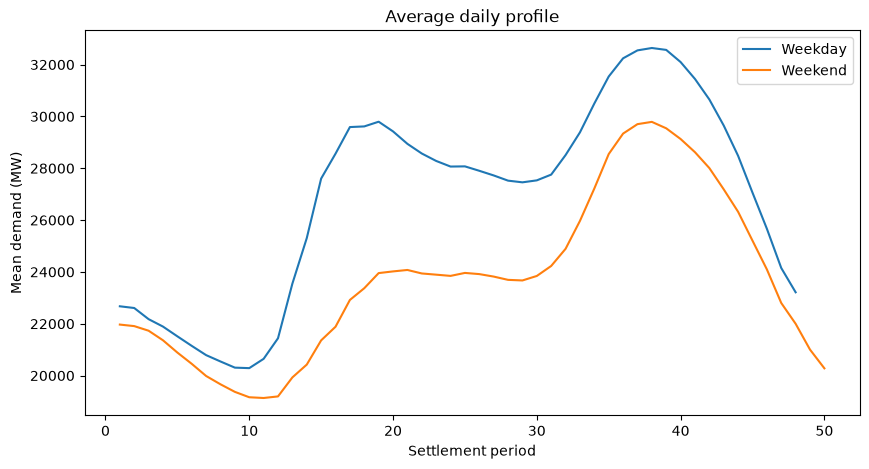

In [5]:
#Weekday vs weekend demand by half hour

d = demand.copy()
d["period"] = d["settlementPeriod"]
d["weekend"] = d["startTime"].dt.dayofweek >= 5

profile = d.groupby(["period", "weekend"])["initialDemandOutturn"].mean().unstack()

plt.figure(figsize=(10, 5))
plt.plot(profile.index, profile[False], label="Weekday")
plt.plot(profile.index, profile[True], label="Weekend")
plt.xlabel("Settlement period")
plt.ylabel("Mean demand (MW)")
plt.title("Average daily profile")
plt.legend()
plt.show()

Both day types share the same daily structure; overnight lows near period 10, morning ramp, plateau, evening peak at around period 38. The weekend difference is concentrated in the morning. At period 17 weekdays average 29.5 GW against 22 GW at weekends, a 7.5 GW gap that narrows to around 3 GW at the evening peak.

The gap varies by time of day rather than being a constant offset, so the model should receive both settlement period and day of week rather than a single weekend flag. Periods 49 and 50 appear only on autumn clock change sundays and are averaged over very few observations.

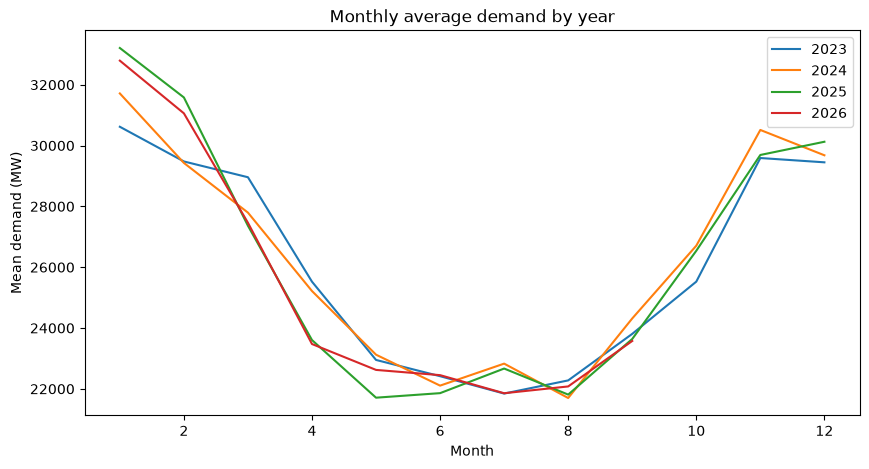

In [6]:
#Demand by month and year

d = demand.copy()
d["year"] = d["startTime"].dt.year
d["month"] = d["startTime"].dt.month

monthly = d.groupby(["year", "month"])["initialDemandOutturn"].mean().unstack(0)

plt.figure(figsize=(10, 5))
for year in monthly.columns:
    plt.plot(monthly.index, monthly[year], label=year)
plt.xlabel("Month")
plt.ylabel("Mean demand (MW)")
plt.title("Monthly average demand by year")
plt.legend()
plt.show()

Monthly averages follow the same seasonal curve in all four years, around 31–33 GW in January, falling to the lowest in July, near 22 GW. The winter spread between years reflects mild versus cold winters, not a trend, since the ordering is not chronological.

There is no evidence of demand drifting up or down across the period, so all three years are equally representative and the full history is usable for training.

In [7]:
#Autocorrelation of demand

d = demand.set_index("startTime")["initialDemandOutturn"]

for lag in [1, 2, 4, 24, 47, 48, 49, 96, 336, 672]:
    print(f"lag {lag:4} ({lag/48:5.2f} days): {d.autocorr(lag):.3f}")

lag    1 ( 0.02 days): 0.989
lag    2 ( 0.04 days): 0.961
lag    4 ( 0.08 days): 0.863
lag   24 ( 0.50 days): 0.244
lag   47 ( 0.98 days): 0.898
lag   48 ( 1.00 days): 0.906
lag   49 ( 1.02 days): 0.895
lag   96 ( 2.00 days): 0.830
lag  336 ( 7.00 days): 0.891
lag  672 (14.00 days): 0.850


Lag 1 correlates at 0.989, meaning demand is highly persistent half hour to half hour. Lag 24 drops to 0.244, the opposite phase of the daily cycle. The daily pattern reappears at lag 48 (0.906), slightly above its neighbours at 47 and 49, confirming the exact offset matters.

Lag 336 (one week) reaches 0.891, almost matching lag 48 despite being seven times further back. Decay is slow, with two weeks back still at 0.850.

Candidate lags for the model: 1, 2, 48 and 336. Which are usable depends on the forecast horizon, since short lags will not be available when predicting a day ahead.

In [8]:
#Holiday effects on demand

daily = demand.set_index("startTime")["initialDemandOutturn"].resample("D").mean()

for date in ["2023-12-25", "2024-12-25", "2025-12-25", "2023-01-01", "2024-01-01"]:
    print(f"{date}: {daily.loc[date]:.0f} MW")

print(f"\nDecember 2023 average: {daily['2023-12'].mean():.0f} MW")
print(f"December 2024 average: {daily['2024-12'].mean():.0f} MW")

2023-12-25: 22675 MW
2024-12-25: 24470 MW
2025-12-25: 25292 MW
2023-01-01: 24093 MW
2024-01-01: 25175 MW

December 2023 average: 29447 MW
December 2024 average: 29681 MW


Christmas Day runs 15–23% below the December average across three years (22,675 MW against 29,447 in 2023). New year's shows a similar 15–18% drop. These gaps are comparable in size to the weekday/weekend difference.

With only a few holidays per year in the training data, the model can't learn this from date patterns alone, so a bank holiday flag is needed. The UK holidays package covers all of them, including Easter, which moves year to year and could not be inferred from month and day features.

In [9]:
#Wind and temperature correlation with demand

print(merged[["temperature_2m", "wind_speed_10m", "initialDemandOutturn"]].corr())

                      temperature_2m  wind_speed_10m  initialDemandOutturn
temperature_2m              1.000000        0.068494             -0.402359
wind_speed_10m              0.068494        1.000000              0.033299
initialDemandOutturn       -0.402359        0.033299              1.000000


Wind speed correlates with demand at 0.033, effectively no relationship, so its excluded from the demand model's features. Temperature correlates at −0.402, confirming the heating relationship, though this understates it, as correlation measures linear association and the relationship doesnt change above 15°C, so a heating degree day feature should score higher.

Wind is kept in the ingested data for the price model at a later stage, where wind generation is a driver.

In [10]:
#Gaps on the two 47 days

for date in ["2023-07-17", "2023-12-29"]:
    day = demand[demand["settlementDate"] == date]
    missing = set(range(1, 49)) - set(day["settlementPeriod"])
    print(f"{date}: missing period(s) {missing}")

2023-07-17: missing period(s) {45}
2023-12-29: missing period(s) {8}


The two incomplete days are missing single periods: period 8 (03:30) on 2023-07-17 and period 45 (22:00) on 2023-12-29. Both fall in slow changing parts of the daily cycle, so linear interpolation between neighbouring values is fine.

To summerize:

- Demand structure: Time of day is the dominant driver, peak to lowest within a day is roughly 2x, larger than the seasonal swing. Weekdays and weekends share the same shape, but the gap between them varies by time of day (7.5 GW at the morning ramp, around 3 GW at the evening peak), so the model needs both settlement period and day of week rather than a single weekend flag.

- Weather: Demand falls with temperature below roughly 15°C and plateus above it, with no cooling driven upturn. A heating degree day feature suits this better than raw temperature. Wind correlates at 0.033 and is excluded.

- Lags: Autocorrelation is 0.989 at one step, 0.906 at one day and 0.891 at one week. Candidates are 1, 2, 48 and 336, though which are usable depends on the forecast horizon, since short lags will not be available when predicting a day ahead.

- Holidays: Christmas and New Year run 15–23% below the monthly average, comparable to the weekday/weekend gap. Too few instances for the model to learn from dates alone, so an UK bank holiday flag is needed.

- Stability: All 4 years follow the same seasonal curve with no drift, so the full history is usable for training.

- For preprocessing: 2 single period gaps (2023-07-17 period 8, 2023-12-29 period 45) both fall in slow changing parts of the day and can be interpolated. Demand is half hourly and weather hourly, so the two need aligning on startTime (UTC as settlementDate shifts under British Summer Time).